# 01 — Exploratory Data Analysis

**Kaggle:** Add Input → *140k Real and Fake Faces*; Accelerator = None (CPU is enough); Internet = On.

Theory and explanation: [`docs/02_exploratory_data_analysis.md`](../docs/02_exploratory_data_analysis.md)

In [1]:
# --- environment setup: works on Kaggle, Colab and locally ---
import sys, os
REPO = "https://github.com/Mohd2Shaan/Deepfake-Detection-Project.git"
ON_KAGGLE = os.path.exists("/kaggle/input")
ON_COLAB = "google.colab" in sys.modules
if ON_KAGGLE or ON_COLAB:
    PROJECT = "/kaggle/working/project" if ON_KAGGLE else "/content/project"
    if os.path.exists(PROJECT):
        !git -C {PROJECT} pull -q
    else:
        !git clone -q {REPO} {PROJECT}
    %cd {PROJECT}
    EXTRA = "" if ON_KAGGLE else "kagglehub"
    !pip install -q grad-cam {EXTRA}
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("working dir:", os.getcwd())

/kaggle/working/project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
working dir: /kaggle/working/project


In [2]:
# --- dataset: Kaggle -> attached input is found automatically; Colab/local -> downloaded once (~4 GB) ---
from src import config
if ON_KAGGLE:
    for ckpt in config.import_kaggle_checkpoints():      # notebooks 03/04: models from notebook 02's output
        print("trained model:", ckpt)
if not (config.DATA_DIR / "train").exists():
    if ON_KAGGLE:
        raise RuntimeError("Dataset not found - attach '140k Real and Fake Faces' with Add Input")
    !python scripts/download_dataset.py --move
print("data dir:", config.DATA_DIR)

data dir: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake


In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from src import eda, config
from src.dataset import get_dataloaders, save_batch_grid

## 1. Scan every image
The full dataset takes ~10 min on Kaggle. Set `MAX_PER_CLASS = 2000` for a quick look.

In [4]:
MAX_PER_CLASS = None
df = eda.scan_images(eda.list_images(max_per_class=MAX_PER_CLASS))
df.head()

scanning: 100%|██████████| 140000/140000 [16:38<00:00, 140.18it/s]


,path,split,class,label,width,height,mode,file_kb,md5,corrupted
0,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,train,real,0,256,256,RGB,26.946289,e07bc9822451f2446229cd55f5c1c6fc,False
1,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,train,real,0,256,256,RGB,23.041992,18d4d7c70736d0495dc5be07cf5d9895,False
2,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,train,real,0,256,256,RGB,26.388672,86fabd12ce159c4624a6f607cb87cc1c,False
3,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,train,real,0,256,256,RGB,26.090820,219a5892826e24d0653876ba9e16b129,False
4,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,train,real,0,256,256,RGB,23.814453,97717a99287727247b8612270bb0dbcf,False


## 2. Class balance

class,real,fake
split,,
train,50000,50000
valid,10000,10000
test,10000,10000


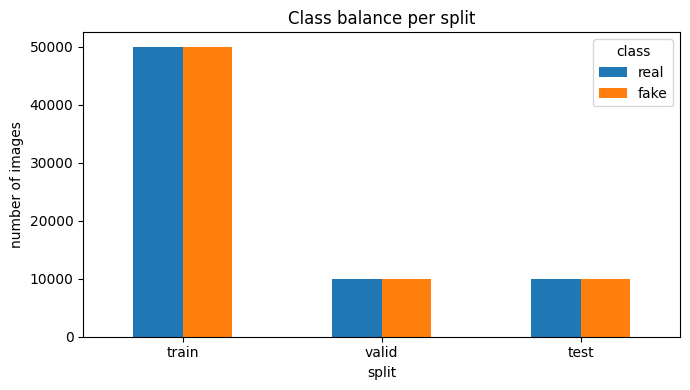

In [5]:
eda.plot_class_balance(df, config.PLOTS_DIR / 'eda_class_balance.png')

## 3. Image size, colour mode, corrupted files, duplicates

In [6]:
print(df.groupby(['width', 'height']).size())
print(df['mode'].value_counts())
print('corrupted:', int(df['corrupted'].sum()))
dups = eda.find_duplicates(df)
print('duplicates:', len(dups))
dups.head()

width  height
256    256       140000
dtype: int64
mode
RGB    140000
Name: count, dtype: int64
corrupted: 0
duplicates: 0


,path,split,class,md5


## 4. Random samples

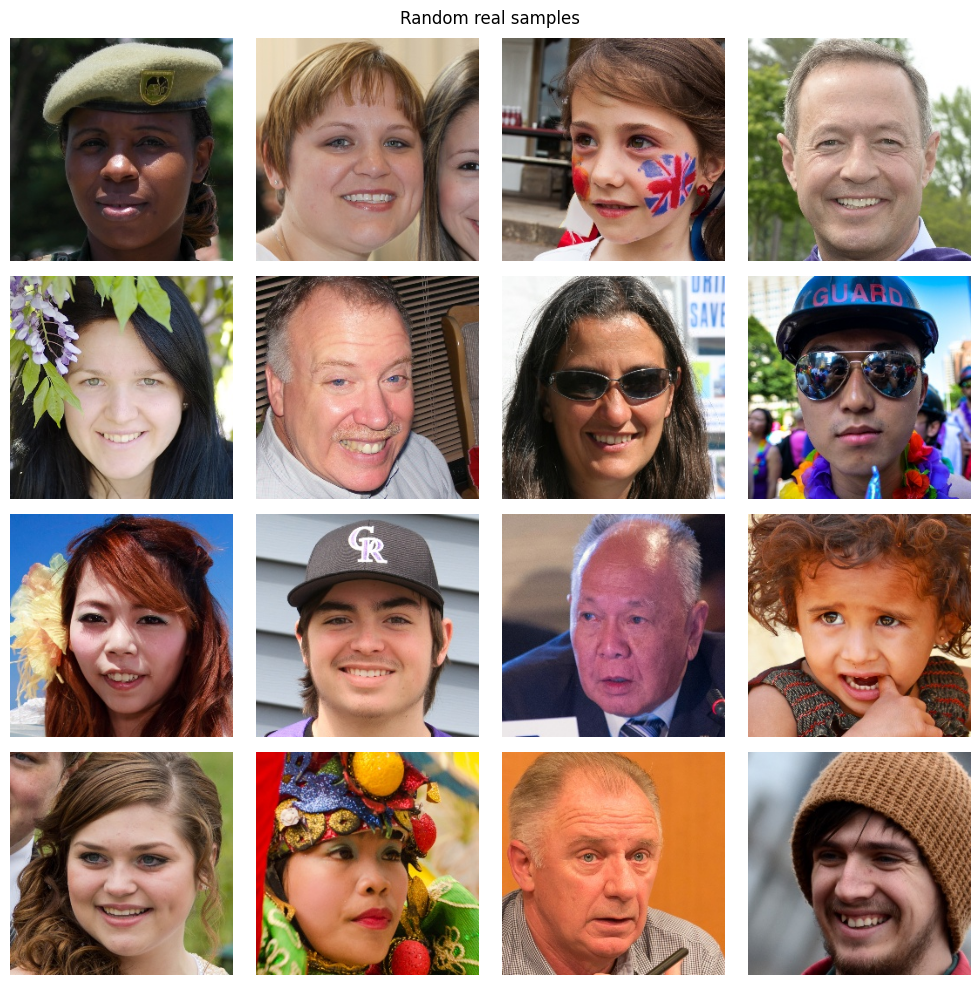

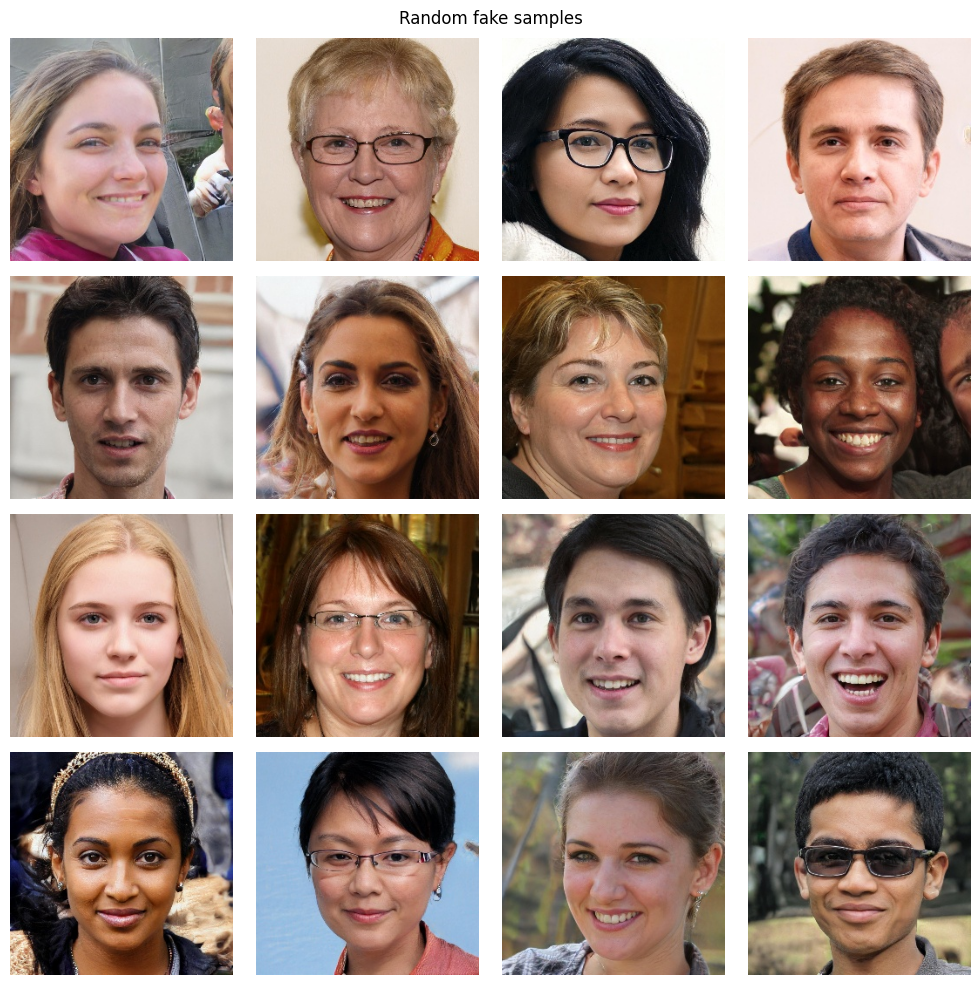

In [7]:
for c in config.CLASS_NAMES:
    eda.plot_sample_grid(df, c, out_path=config.PLOTS_DIR / f'eda_samples_{c}.png')
    plt.show()

## 5. File size distribution (shortcut check)

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
fake,70000.0,27.759707,3.858155,15.382812,25.055420,27.334961,30.015869,52.270508
real,70000.0,28.259544,3.879695,13.479492,25.566406,28.051758,30.699219,50.474609


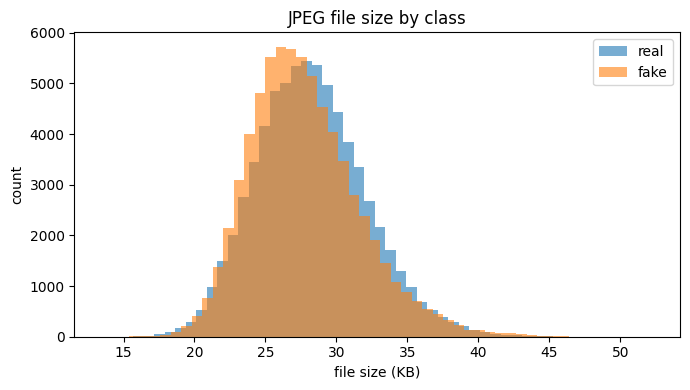

In [8]:
eda.plot_file_size_distribution(df, config.PLOTS_DIR / 'eda_file_size.png')
df.groupby('class')['file_kb'].describe()

## 6. Mean face and mean Fourier spectrum

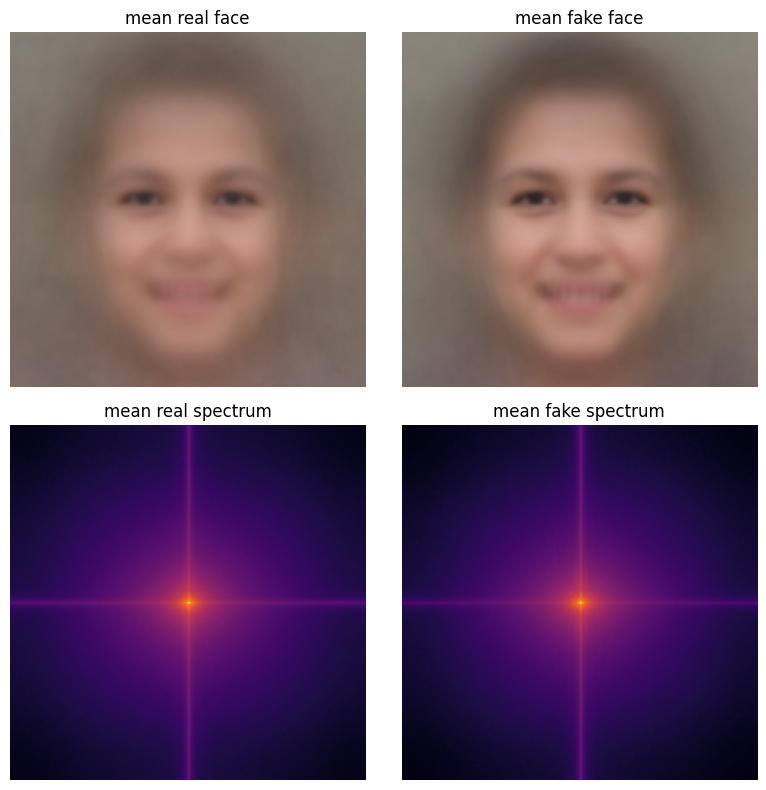

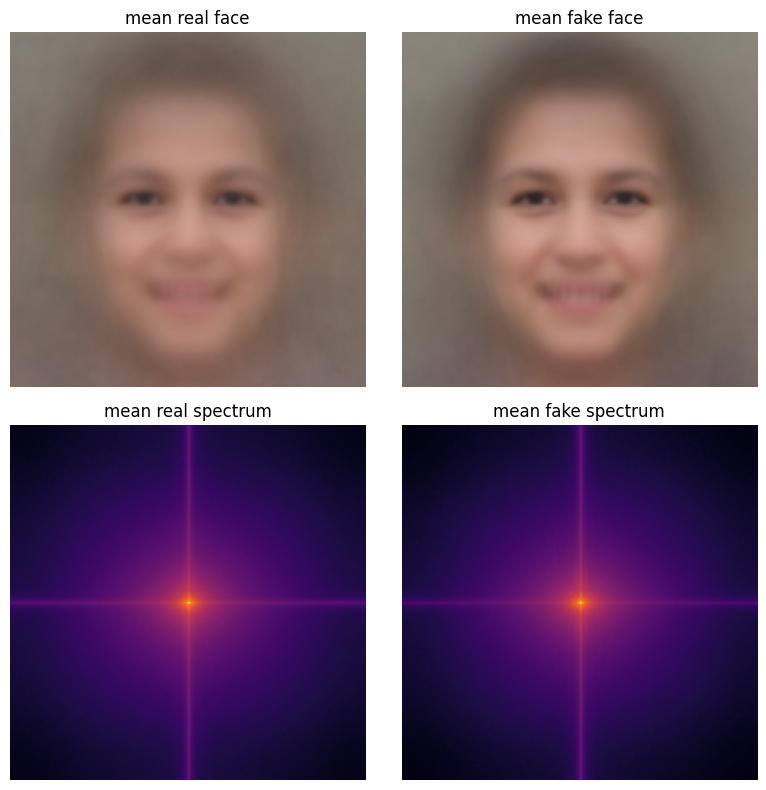

In [9]:
eda.plot_mean_faces_and_spectra(df, n=500, out_path=config.PLOTS_DIR / 'eda_mean_face_spectrum.png')

## 7. Sanity check — a batch after transforms

train 100000 {'real': 50000, 'fake': 50000}
valid 20000 {'real': 10000, 'fake': 10000}
test 20000 {'real': 10000, 'fake': 10000}


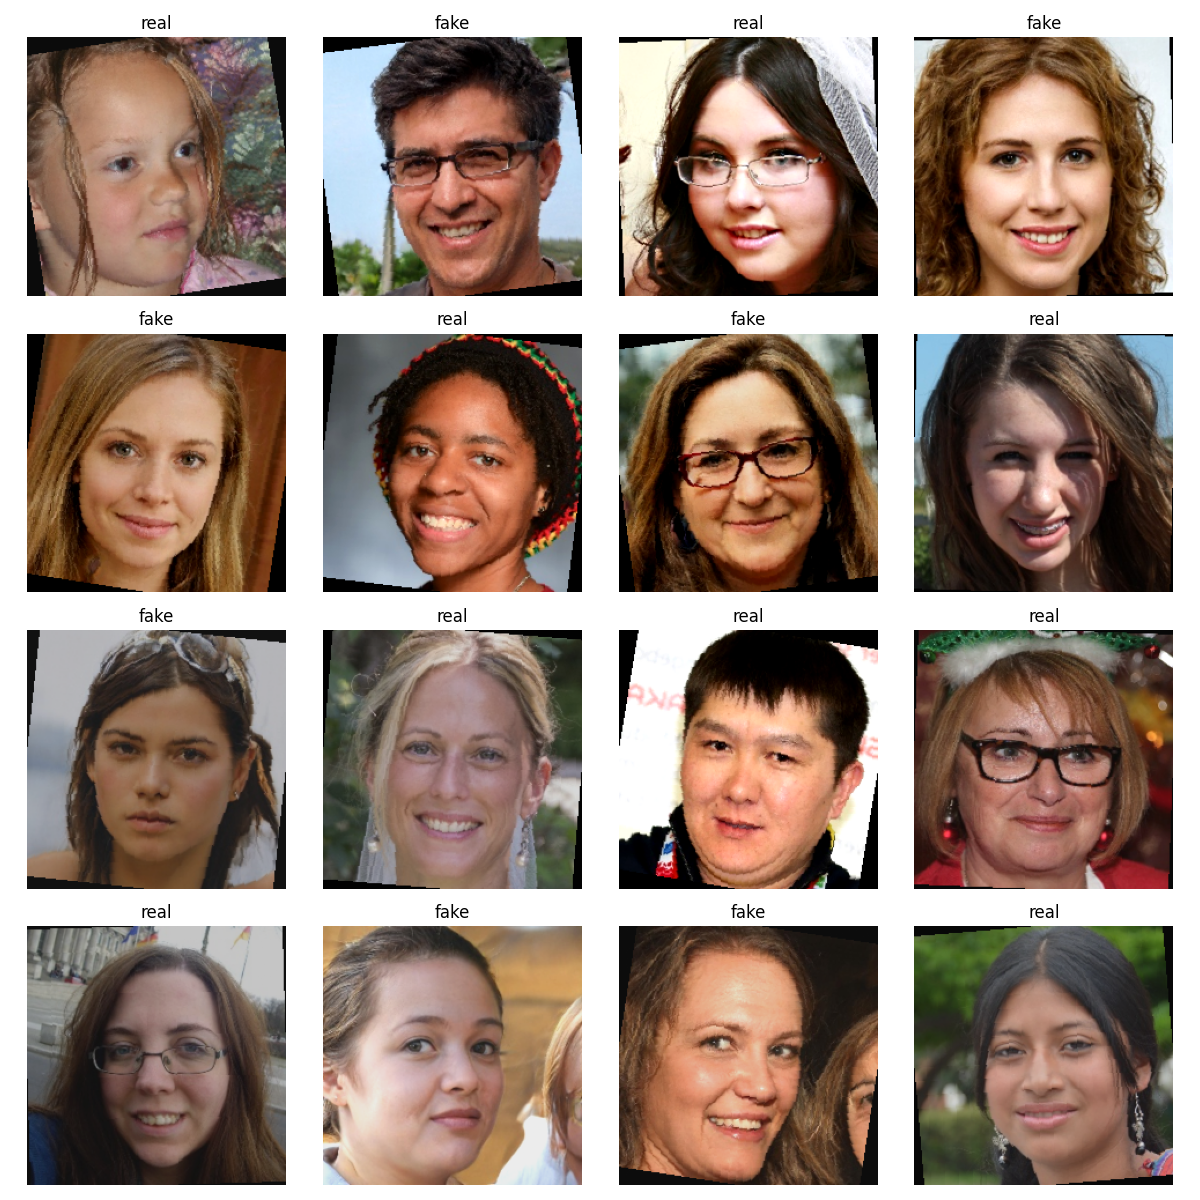

In [11]:
loaders = get_dataloaders(num_workers=0)
for split, loader in loaders.items():
    print(split, len(loader.dataset), loader.dataset.class_counts())
save_batch_grid(loaders['train'], config.PLOTS_DIR / 'sample_train_batch.png')
from IPython.display import Image as Show
Show(str(config.PLOTS_DIR / 'sample_train_batch.png'))

## Observations (full dataset, 140,000 images, run on Kaggle)

| Check | Result |
|-------|--------|
| Split sizes | train 100,000 · valid 20,000 · test 20,000 |
| Class balance | exactly 50 / 50 in every split |
| Image size / mode | all 140,000 images are 256×256 RGB |
| Corrupted files | 0 |
| Exact duplicates (MD5) | 0 — none within or across splits |
| Mean JPEG size | real 28.26 KB (σ 3.88) · fake 27.76 KB (σ 3.86) |

1. **Clean and balanced.** No corrupted files, no duplicates, perfectly balanced classes → accuracy is a fair metric
   and the 0.5 threshold is appropriate. No cleaning needed.
2. **No file-size shortcut.** The two histograms overlap almost completely; fakes are only ~0.5 KB smaller on average
   (≈0.13 standard deviations), consistent with GAN images having slightly smoother textures that compress a bit
   better. Far too weak to separate the classes, so the model cannot rely on compression level.
3. **Humans can't tell them apart.** Random samples of both classes look like ordinary portraits. Some fakes show
   odd backgrounds (warped objects, half-formed second faces at the borders) — candidates for Grad-CAM to highlight.
4. **Mean faces.** Both classes are face-centred and aligned (FFHQ alignment). The mean fake face is noticeably
   *sharper* (eyes, smile) than the mean real face → StyleGAN faces are more uniform in pose/alignment, while real
   photos vary more.
5. **Mean Fourier spectra look almost identical.** No obvious GAN up-sampling peaks are visible in the averaged
   log-spectrum at this resolution (the bright cross is a border effect of the FFT). So the real/fake difference is
   subtle and local — a job for a CNN rather than a simple global frequency rule.
6. **Pipeline sanity check passed.** Transformed batches show correct labels and mild augmentation (flip, ±10°
   rotation, brightness/contrast). Rotation adds black corners to *both* classes equally, so it does not leak the label.
